# Classification ❤︎ - Sınıflandırma ❤︎ y= EVET-HAYIR-VAR-YOK

Classification cevabı evet hayır veya pozitif, negatif, nötr gibi olan modellerle kullanılır.
    Bu projede binlerce çalışanı olan  bir şirket çalışanlarının işten ayrılıp ayrılmayacağını tahmin eden bir model geliştireceğiz.

In [3]:
import pandas as pd

In [6]:
pd.set_option('display.max_columns',100)

In [7]:
import warnings 

In [8]:
warnings.filterwarnings('ignore')

In [9]:
import matplotlib.pyplot as plt

In [10]:
import seaborn as sns

In [11]:
df=pd.read_csv('hr_data.csv')

In [12]:
df.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
0,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,2,5993.0,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5,Yes
1,49,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,1,5130.0,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7,No
2,37,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,2,2090.0,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0,Yes
3,33,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,1,2909.0,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0,No
4,27,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,1,3468.0,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2,No


## EDA - Explotoray Data Analysis ❤︎

In [14]:
df.head(1)

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
0,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,2,5993.0,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5,Yes


In [15]:
df.sample()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
1210,33,Travel_Rarely,267,Research & Development,21,3,Medical,1,1698,2,Male,79,4,1,Laboratory Technician,2,1,2028.0,13637,1,Y,No,18,3,4,80,3,14,6,3,14,11,2,13,No


In [16]:
df.isnull().sum()

Age                           0
BusinessTravel                0
DailyRate                     0
Department                    0
DistanceFromHome              0
Education                     0
EducationField                0
EmployeeCount                 0
EmployeeNumber                0
EnvironmentSatisfaction       0
Gender                        0
HourlyRate                    0
JobInvolvement                0
JobLevel                      0
JobRole                       0
JobSatisfaction               0
MaritalStatus                 0
MonthlyIncome                 0
MonthlyRate                   0
NumCompaniesWorked            0
Over18                        0
OverTime                      0
PercentSalaryHike             0
PerformanceRating             0
RelationshipSatisfaction      0
StandardHours                 0
StockOptionLevel              0
TotalWorkingYears             0
TrainingTimesLastYear         0
WorkLifeBalance               0
YearsAtCompany                0
YearsInC

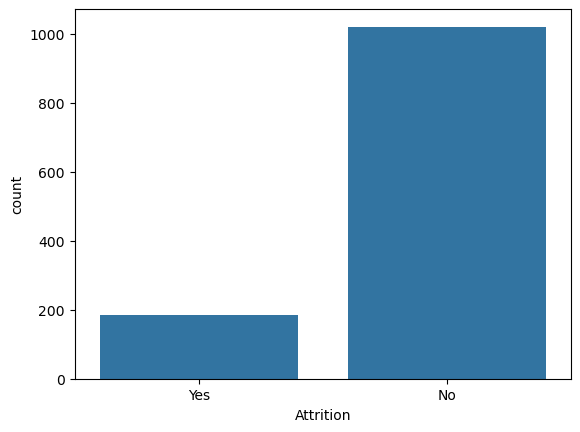

In [20]:
sns.countplot(x=df['Attrition']);

In [21]:
df['Attrition'].unique()

array(['Yes', 'No', nan], dtype=object)

In [22]:
df.shape

(1470, 35)

In [23]:
d={'No':0,'Yes':1}

In [24]:
df['Attrition']=df['Attrition'].map(d) #fo döngüsünün modern hali

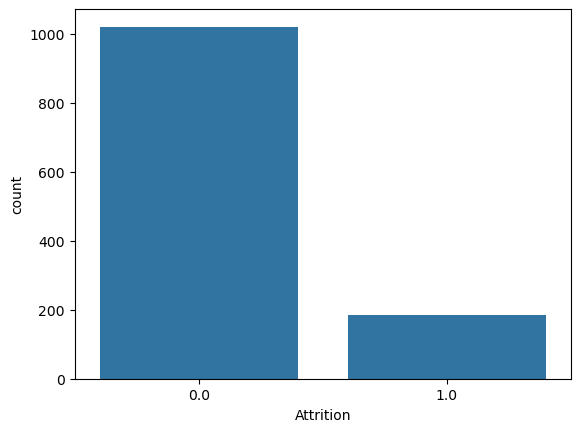

In [25]:
sns.countplot(x=df['Attrition']);

In [27]:
bos=df[df['Attrition'].isnull()]
dolu=df[df['Attrition'].notnull()]

In [28]:
dolu.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
0,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,2,5993.0,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5,1.0
1,49,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,1,5130.0,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7,0.0
2,37,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,2,2090.0,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0,1.0
3,33,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,1,2909.0,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0,0.0
4,27,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,1,3468.0,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2,0.0


In [29]:
bos.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
367,50,Travel_Rarely,1046,Research & Development,10,3,Technical Degree,1,491,4,Male,100,2,3,Healthcare Representative,4,2,9587.987822,2755,6,Y,No,15,3,4,80,0,20,2,3,4,3,1,3,NaN
368,40,Travel_Rarely,575,Sales,22,2,Marketing,1,492,3,Male,68,2,2,Sales Executive,3,1,5910.500884,6110,2,Y,Yes,12,3,1,80,2,8,6,3,6,4,1,0,NaN
369,31,Travel_Rarely,408,Research & Development,9,4,Life Sciences,1,493,3,Male,42,2,1,Research Scientist,2,2,2611.940519,7551,0,Y,Yes,16,3,4,80,0,3,5,3,2,2,2,2,NaN
370,21,Travel_Rarely,156,Sales,12,3,Life Sciences,1,494,3,Female,90,4,1,Sales Representative,2,2,1963.485226,25422,1,Y,No,15,3,4,80,0,1,0,3,1,0,0,0,NaN
371,29,Travel_Rarely,1283,Research & Development,23,3,Life Sciences,1,495,4,Male,54,3,1,Research Scientist,4,2,2761.033309,18168,9,Y,No,16,3,4,80,0,6,4,3,3,2,1,2,NaN


In [30]:
x=dolu.drop('Attrition', axis=1)

In [33]:
df = df.dropna(subset=['Attrition'])

In [34]:
df['Attrition']=df['Attrition'].astype(int) ##içerisinde bos değerler olduğu icin olmamıstı simdi tekrar deneyeceğiz

In [37]:
x=pd.get_dummies(x, drop_first=True) 
#❤︎get_dummies : EducationField gibi string olan ifadeleri rakama çeviriyoruz❤︎ : Hatirla  0 0 0 1, 1 0 0 0 

In [38]:
x.shape


(1205, 46)

In [39]:
x.head()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,Gender_Male,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,OverTime_Yes
0,41,1102,1,2,1,1,2,94,3,2,4,2,5993.0,19479,8,11,3,1,80,0,8,0,1,6,4,0,5,False,True,False,True,True,False,False,False,False,False,False,False,False,False,False,False,True,False,True
1,49,279,8,1,1,2,3,61,2,2,2,1,5130.0,24907,1,23,4,4,80,1,10,3,3,10,7,1,7,True,False,True,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,False
2,37,1373,2,2,1,4,4,92,2,1,3,2,2090.0,2396,6,15,3,2,80,0,7,3,3,0,0,0,0,False,True,True,False,False,False,False,True,False,True,False,True,False,False,False,False,False,False,True
3,33,1392,3,4,1,5,4,56,3,1,3,1,2909.0,23159,1,11,3,3,80,0,8,3,3,8,7,3,0,True,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True
4,27,591,2,1,1,7,1,40,3,1,2,1,3468.0,16632,9,12,3,4,80,1,6,3,3,2,2,2,2,False,True,True,False,False,False,True,False,False,True,False,True,False,False,False,False,False,False,False


In [49]:
# Target (hedef)
y = df['Attrition']

# Feature set (Attrition hariç)
X = df.drop('Attrition', axis=1)


In [50]:
x_train, x_test, y_train, y_test= train_test_split(x,y, test_size=.15, random_state=12)

In [51]:
X = pd.get_dummies(X, drop_first=True)

In [52]:
print(X.shape)
print(y.shape)
## tekrar dummy testi :)

(1205, 46)
(1205,)


In [53]:
from sklearn.naive_bayes import GaussianNB

In [54]:
from sklearn.naive_bayes import BernoulliNB

In [55]:
g=GaussianNB()

In [56]:
b=BernoulliNB()

In [57]:
g.fit(x_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [58]:
b.fit(x_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"binarize binarize: float or None, default=0.0Threshold for binarizing (mapping to booleans) of sample features.If None, input is presumed to already consist of binary vectors.",0.0
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [60]:
gtahmin=g.predict(x_test)

In [90]:
btahmin=b.predict(x_test)

In [62]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [63]:
accuracy_score(y_test,gtahmin)

0.8176795580110497

In [64]:
confusion_matrix(y_test,gtahmin)

array([[128,  20],
       [ 13,  20]])

In [66]:
print(classification_report(y_test,gtahmin))

              precision    recall  f1-score   support

           0       0.91      0.86      0.89       148
           1       0.50      0.61      0.55        33

    accuracy                           0.82       181
   macro avg       0.70      0.74      0.72       181
weighted avg       0.83      0.82      0.82       181



<Axes: >

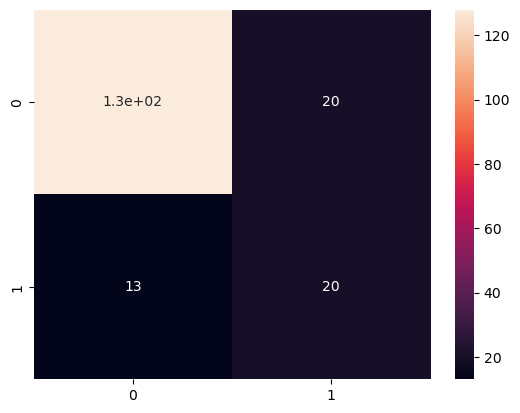

In [67]:
sns.heatmap(confusion_matrix(y_test,gtahmin), annot=True) 

In [88]:
from yellowbrick.classifier import roc_auc
from yellowbrick.datasets import load_spa
visualizer = roc_auc(GaussianNB(), x, y)

ImportError: cannot import name 'load_spa' from 'yellowbrick.datasets' (C:\Anaconda3\Lib\site-packages\yellowbrick\datasets\__init__.py)

In [83]:
y_train.value_counts()

Attrition
0    816
1    148
Name: count, dtype: int64

In [84]:
y_train.dtype

dtype('int64')

In [85]:
from sklearn.base import is_classifier
is_classifier(model)

True

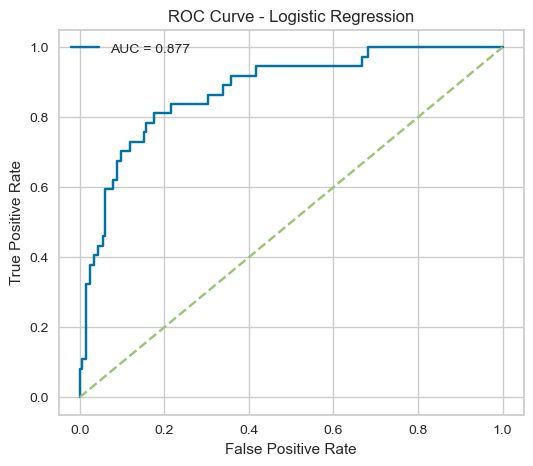

In [86]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

model = LogisticRegression(max_iter=1000, solver="liblinear")
model.fit(X_train, y_train)

y_proba = model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

In [97]:
# 1. NaN değerleri kontrol et
print("NaN değer sayısı:")
print(df.isnull().sum())

NaN değer sayısı:
Age                         0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotio

In [98]:
df = df.dropna(subset=['Attrition'])

In [99]:
df['Attrition'] = df['Attrition'].astype(int)

In [101]:
print(f"\nTemizlenmiş veri şekli: {df.shape}")
print(f"Attrition değerleri: {df['Attrition'].unique()}")


Temizlenmiş veri şekli: (1205, 35)
Attrition değerleri: [1 0]


In [104]:
# Yeniden feature ve target ayırma
y = df['Attrition']
X = df.drop('Attrition', axis=1)

In [105]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=12)

In [109]:
# Dummy variables
X = pd.get_dummies(X, drop_first=True)

In [110]:
print(confusion_matrix(y_test, btahmin))

[[135  13]
 [ 26   7]]


In [111]:
print(accuracy_score(y_test, btahmin))

0.7845303867403315


In [112]:
print(classification_report(y_test, btahmin))

              precision    recall  f1-score   support

           0       0.84      0.91      0.87       148
           1       0.35      0.21      0.26        33

    accuracy                           0.78       181
   macro avg       0.59      0.56      0.57       181
weighted avg       0.75      0.78      0.76       181



In [165]:
from sklearn.linear_model import LogisticRegression

In [166]:
L=LogisticRegression()

In [167]:
L.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [168]:
Ltahmin=L.predict(x_test)

In [169]:
accuracy_score(y_test, Ltahmin)

0.8232044198895028

In [170]:
confusion_matrix(y_test, btahmin)

array([[135,  13],
       [ 26,   7]])

In [171]:
print(classification_report(y_test, Ltahmin))

              precision    recall  f1-score   support

           0       0.83      0.99      0.90       148
           1       0.67      0.06      0.11        33

    accuracy                           0.82       181
   macro avg       0.75      0.53      0.51       181
weighted avg       0.80      0.82      0.76       181



In [172]:
from sklearn.tree import DecisionTreeClassifier

In [173]:
d=DecisionTreeClassifier()

In [174]:
d.fit(x_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [175]:
dtahmin=d.predict(x_test)

In [176]:
accuracy_score(y_test, dtahmin)

0.7348066298342542

In [177]:
confusion_matrix(y_test, dtahmin)

array([[125,  23],
       [ 25,   8]])

In [178]:
from sklearn.ensemble import RandomForestClassifier

In [179]:
r = RandomForestClassifier()

In [180]:
rtahmin = r.fit(x_train, y_train).predict(x_test)

In [181]:
accuracy_score(y_test, rtahmin)

0.8453038674033149

In [182]:
confusion_matrix(y_test, rtahmin)

array([[147,   1],
       [ 27,   6]])

In [183]:
from sklearn.neighbors import KNeighborsClassifier

In [184]:
k = KNeighborsClassifier()

In [185]:
ktahmin=k.fit(x_train,y_train).predict(x_test)

In [186]:
accuracy_score(y_test, ktahmin)

0.8066298342541437

In [187]:
confusion_matrix(y_test, ktahmin)

array([[145,   3],
       [ 32,   1]])

In [189]:
from sklearn.ensemble import GradientBoostingClassifier

In [190]:
h= GradientBoostingClassifier()

In [191]:
htahmin = h.fit(x_train, y_train).predict(x_test)

In [192]:
accuracy_score(y_test,htahmin)

0.856353591160221

In [193]:
confusion_matrix(y_test, htahmin)

array([[146,   2],
       [ 24,   9]])

In [197]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import BernoulliNB

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import pandas as pd

# Modelleri tanımla
b = BernoulliNB()
l = LogisticRegression(max_iter=1000, solver='liblinear')
d = DecisionTreeClassifier()
r = RandomForestClassifier()
gb = GradientBoostingClassifier()
kn = KNeighborsClassifier()
ab = AdaBoostClassifier()
mn = MultinomialNB()

def algo_test(x, y):
    """
    Tüm classification modellerini test eder ve performanslarını karşılaştırır
    
    Parameters:
    -----------
    x : DataFrame veya array
        Feature verisi
    y : Series veya array
        Target değişken
    
    Returns:
    --------
    DataFrame : Tüm modellerin performans metrikleri
    """
    
    # Model listesi
    modeller = [b, l, d, r, gb, kn, ab, mn]
    isimler = ["BernoulliNB", "LogisticRegression", "DecisionTreeClassifier",
               "RandomForestClassifier", "GradientBoostingClassifier", "KNeighborsClassifier",
               "AdaBoostClassifier", "MultinomialNB"]
    
    # Train-test split
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)
    
    # Metrik listeleri
    accuracy = []
    precision = []
    recall = []
    f1 = []
    mdl = []
    
    print("Veriler hazır modeller deneniyor")
    print("="*60)
    
    for model, isim in zip(modeller, isimler):
        print(f"{isim} modeli eğitiliyor!..")
        
        # Model eğitimi
        model = model.fit(x_train, y_train)
        
        # Tahmin
        tahmin = model.predict(x_test)
        
        # Model kaydı
        mdl.append(model)
        
        # Metrikleri hesapla
        accuracy.append(accuracy_score(y_test, tahmin))
        precision.append(precision_score(y_test, tahmin, average="micro"))
        recall.append(recall_score(y_test, tahmin, average="micro"))
        f1.append(f1_score(y_test, tahmin, average="micro"))
        
        # Confusion matrix yazdır
        print(confusion_matrix(y_test, tahmin))
        
    print("="*60)
    print("Eğitim tamamlandı.")
    print()
    
    # Sonuçları DataFrame'e çevir
    metrics = pd.DataFrame(columns=["Accuracy", "Precision", "Recall", "F1", "Model"], 
                          index=isimler)
    metrics["Accuracy"] = accuracy
    metrics["Precision"] = precision
    metrics["Recall"] = recall
    metrics["F1"] = f1
    metrics["Model"] = mdl
    
    # F1 skoruna göre sırala (azalan)
    metrics.sort_values("F1", ascending=False, inplace=True)
    
    # En başarılı modeli yazdır
    print("En başarılı model: ", metrics.iloc[0].name)
    print()
    
    # En iyi modeli seç
    model = metrics.iloc[0, -1]
    
    # En iyi model için detaylı sonuçlar
    tahmin = model.predict(np.array(x_test) if model == kn else x_test)
    
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, tahmin))
    print()
    
    print("Classification Report:")
    print(classification_report(y_test, tahmin))
    print()
    
    print("Diğer Modeller:")
    print()
    
    # Model sütununu çıkarıp göster
    return metrics.drop("Model", axis=1)

Veriler hazır modeller deneniyor
BernoulliNB modeli eğitiliyor!..
[[192  19]
 [ 23   7]]
LogisticRegression modeli eğitiliyor!..
[[206   5]
 [ 19  11]]
DecisionTreeClassifier modeli eğitiliyor!..
[[182  29]
 [ 19  11]]
RandomForestClassifier modeli eğitiliyor!..
[[211   0]
 [ 27   3]]
GradientBoostingClassifier modeli eğitiliyor!..
[[208   3]
 [ 24   6]]
KNeighborsClassifier modeli eğitiliyor!..
[[205   6]
 [ 29   1]]
AdaBoostClassifier modeli eğitiliyor!..
[[204   7]
 [ 21   9]]
MultinomialNB modeli eğitiliyor!..
[[115  96]
 [  9  21]]
Eğitim tamamlandı.

En başarılı model:  LogisticRegression

Confusion Matrix:
[[206   5]
 [ 19  11]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.98      0.94       211
           1       0.69      0.37      0.48        30

    accuracy                           0.90       241
   macro avg       0.80      0.67      0.71       241
weighted avg       0.89      0.90      0.89       241


Diğe

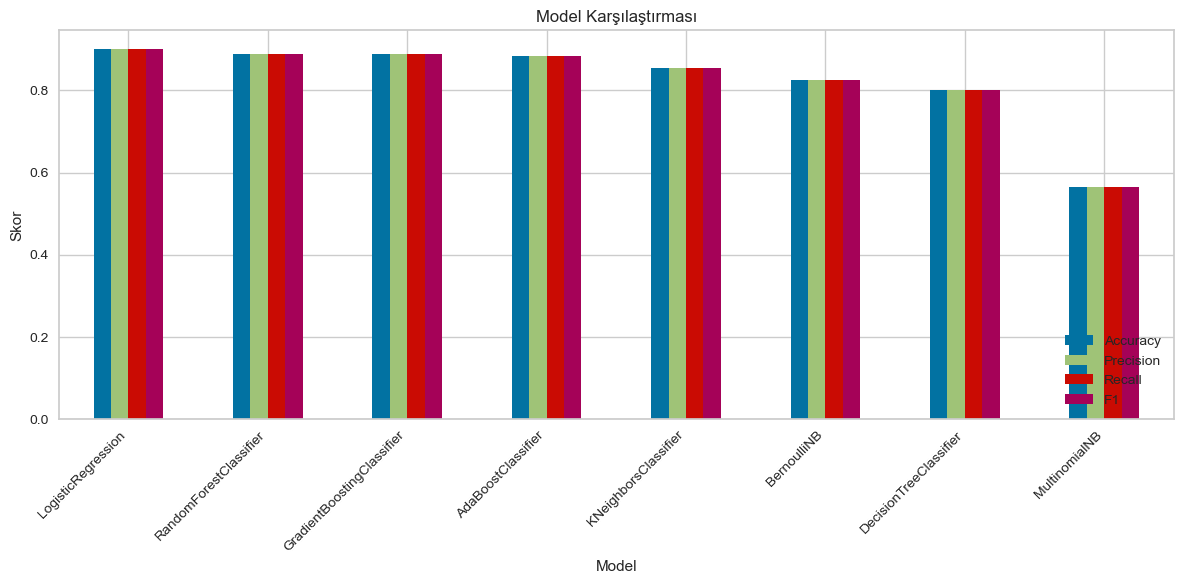

In [198]:
# Fonksiyonu çağır
sonuclar = algo_test(X, y)

# Sonuçları görüntüle
print(sonuclar)

# En iyi 3 modeli göster
print(sonuclar.head(3))

# Görselleştirme
import matplotlib.pyplot as plt

sonuclar[["Accuracy", "Precision", "Recall", "F1"]].plot(kind='bar', figsize=(12, 6))
plt.title("Model Karşılaştırması")
plt.ylabel("Skor")
plt.xlabel("Model")
plt.xticks(rotation=45, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()